**Variance Swap**

It seems like that since VIX is consistently greater then Realized Volatility, we could use that to our advantage and perform a variance swap.

A swap contract is when two parties agree to trade financial cash flows over a set period of time. Often times you are trading varying levels of risk. In our example, are are taking on the risk of spending less on realized volatility, but collecting the premium from implied volatility.

However we wont perform a volatility swap. Volatility swaps have a few drawbacks. Most of import of which are that they are near impossibly to hedge, requiring constant buying and selling of options.

We are calculating the payout as

$$\text{PnL}_{\text{Swap}} = (\text{ VIX })^2 - (\text{ Realized Vol })^2$$


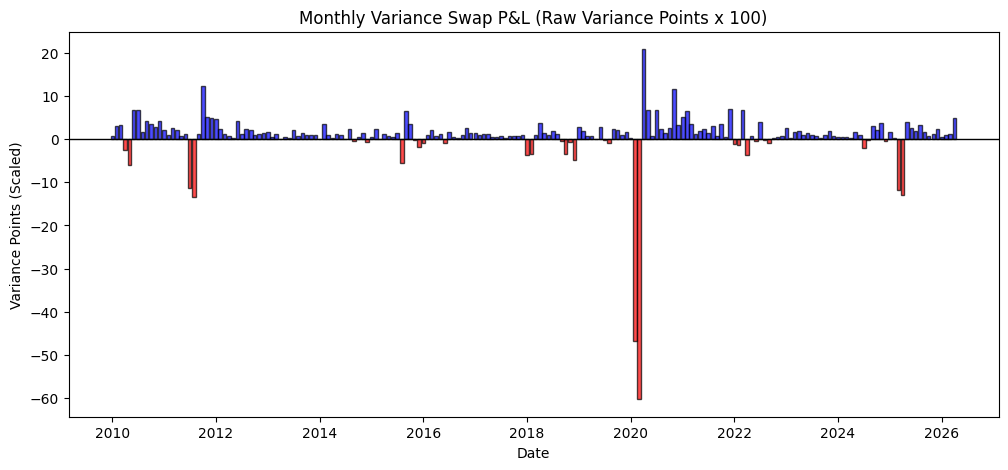

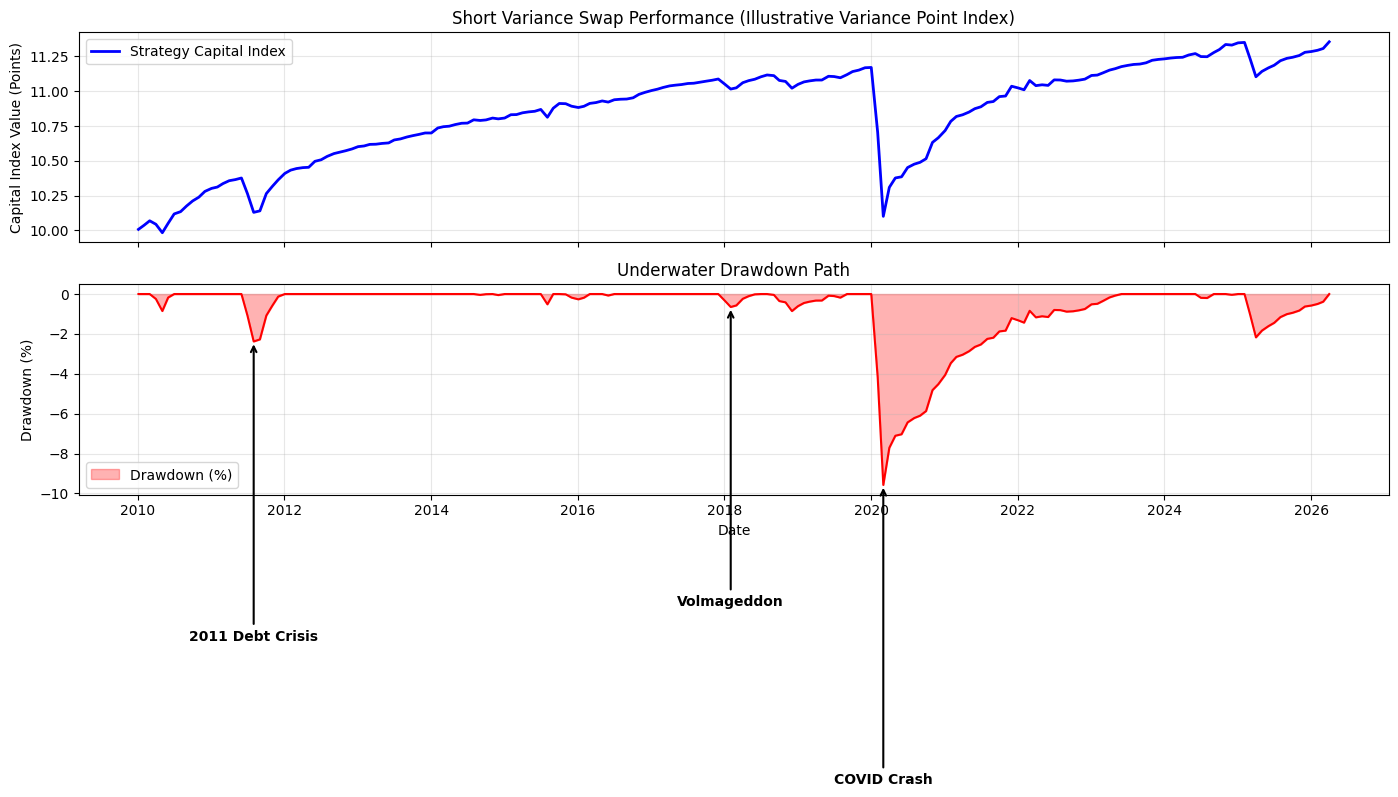

In [1]:
# loadMasterDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/master_dataset.csv', index_col='Date', parse_dates=True)

# sampleMonthlyContracts
df_monthly = df.groupby([df.index.year, df.index.month]).head(1).copy()

# computeVarianceSwapPnL
# P&L = (VIX_decimal)^2 - (Forward_Realized_Vol)^2 (under $1 notional sizing)
df_monthly['pnl'] = (df_monthly['vix_decimal'] ** 2) - (df_monthly['forward_realized_vol'] ** 2)

# plotMonthlyPnLBarChart
plt.figure(figsize=(12, 5))
colors = ['red' if x < 0 else 'blue' for x in df_monthly['pnl']]
plt.bar(df_monthly.index, df_monthly['pnl'] * 100, color=colors, width=25, edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Monthly Variance Swap P&L (Raw Variance Points x 100)')
plt.ylabel('Variance Points (Scaled)')
plt.xlabel('Date')
plt.show()

# computeCumulativeReturns
# We assume starting capital of 10.0 to prevent dividing by zero or going negative in drawdowns
df_monthly['cum_return'] = df_monthly['pnl'].cumsum()
df_monthly['capital_index'] = 10.0 + df_monthly['cum_return']

# computeDrawdowns
# Peak-to-trough drawdown formula: (Current_Value / Rolling_Peak) - 1
df_monthly['rolling_peak'] = df_monthly['capital_index'].cummax()
df_monthly['drawdown'] = (df_monthly['capital_index'] / df_monthly['rolling_peak']) - 1.0

# plotPerformanceAndDrawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: Cumulative return path
ax1.plot(df_monthly.index, df_monthly['capital_index'], color='blue', label='Strategy Capital Index', linewidth=2)
ax1.set_title('Short Variance Swap Performance (Illustrative Variance Point Index)')
ax1.set_ylabel('Capital Index Value (Points)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom panel: Underwater drawdown path
ax2.fill_between(df_monthly.index, df_monthly['drawdown'] * 100, 0, color='red', alpha=0.3, label='Drawdown (%)')
ax2.plot(df_monthly.index, df_monthly['drawdown'] * 100, color='red', linewidth=1.5)
ax2.set_title('Underwater Drawdown Path')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

# Annotate key tail-loss events
tail_events = {
    '2011-08-01': '2011 Debt Crisis',
    '2018-02-05': 'Volmageddon',
    '2020-03-15': 'COVID Crash'
}

for date_str, label in tail_events.items():
    event_date = pd.to_datetime(date_str)
    # Find closest date in index
    closest_date = df_monthly.index[df_monthly.index.get_indexer([event_date], method='nearest')[0]]
    drawdown_val = df_monthly.loc[closest_date, 'drawdown'] * 100

    ax2.annotate(label,
                 xy=(closest_date, drawdown_val),
                 xytext=(closest_date, drawdown_val - 15),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
                 fontsize=10,
                 fontweight='bold',
                 horizontalalignment='center')

plt.tight_layout()
plt.show()

In [2]:
# computeRiskMetrics
# Annualize monthly returns and volatility
ann_return = df_monthly['pnl'].mean() * 12
ann_vol = df_monthly['pnl'].std() * np.sqrt(12)

# Calculate Sharpe Ratio (assuming risk-free rate is 0)
sharpe_ratio = ann_return / ann_vol

# Extract Maximum Drawdown
max_dd = df_monthly['drawdown'].min()

# Calculate Max Drawdown Duration using the calendar-month sampled dataframe
# We find where drawdown is 0 (new peak)
is_at_peak = df_monthly['drawdown'] == 0
peak_dates = df_monthly.index[is_at_peak]

# Compute calendar-month differences between consecutive peaks
if len(peak_dates) > 1:
    # Because df_monthly holds the first trading day of each calendar month,
    # index differences map directly to calendar-month periods.
    peak_indices = np.where(is_at_peak)[0]
    durations = np.diff(peak_indices)
    max_dd_duration = int(durations.max())
else:
    max_dd_duration = len(df_monthly)

# Isolate worst single P&L month
worst_month_pnl = df_monthly['pnl'].min()
worst_month_date = df_monthly['pnl'].idxmin().strftime('%Y-%m')

# printMetricsTable
metrics_data = {
    "Metric": [
        "Annualized Return (Arithmetic Vol-Space)",
        "Annualized Volatility (Variance-PnL)",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Max Drawdown Duration",
        "Worst Month P&L"
    ],
    "Value": [
        f"{ann_return * 100:.2f}%",
        f"{ann_vol * 100:.2f}%",
        f"{sharpe_ratio:.2f}",
        f"{max_dd * 100:.2f}%",
        f"{max_dd_duration} months",
        f"{worst_month_pnl * 100:.2f}% ({worst_month_date})"
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("=== STRATEGY RISK METRICS DASHBOARD ===")
print(metrics_df.to_string(index=False))
print("=======================================")

=== STRATEGY RISK METRICS DASHBOARD ===
                                  Metric             Value
Annualized Return (Arithmetic Vol-Space)             8.29%
    Annualized Volatility (Variance-PnL)            22.44%
                            Sharpe Ratio              0.37
                        Maximum Drawdown            -9.58%
                   Max Drawdown Duration         41 months
                         Worst Month P&L -60.28% (2020-03)


Annualized return: Geometric Average return per year over total duration

Annualized Volatility: Returns how violently your monthly profits bounce up and down around that average return baseline.

Sharpe Ratio: divides your annualized return by your annualized volatility - measures how much return you get for all the risk you take on.

Maximum Drawdown: The greatest difference between a maximum vs its subsequent minimum over a time period. Peak - subsequent Through

Maximum Drawdown Duration: Longest time spent in a drawdown

Worst Month P&L: Month with the greatest losses